# Applied Machine Learning - Homework 3
## Computer Vision & Convolutional Neural Networks (CNNs)

### Learning Objectives
By completing this homework, you will:
1. Understand image representation as 3D tensors (Height × Width × Channels)
2. Implement convolution and pooling operations from scratch
3. Understand parameter sharing and receptive fields in CNNs
4. Explore hierarchical feature learning in deep networks
5. Visualize and analyze CNN filters and activations
6. Compare CNNs with fully connected networks for image tasks

### Instructions
- Complete all TODO sections marked with `# TODO: [Task Description]`
- Run all cells to ensure your implementation works
- Answer the reflection questions in markdown cells
- **Do not modify the provided test functions or baseline code structure**

---

## Setup and Imports

In [13]:
# Essential imports for the homework
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
from scipy import signal
from skimage import data, color, transform
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('default')
sns.set_palette("husl")

print("✅ All imports successful!")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

✅ All imports successful!
NumPy version: 2.4.2
Matplotlib version: 3.10.8


---
# Part 1: Image Representation and 3D Tensors

In this section, you'll understand how images are represented as 3D tensors and work with image data.

### Task 1.1: Load and Visualize Image Data

Image Properties:
Image shape: (512, 512, 3)
Data type: uint8
Value range: [0, 255]
Total pixels: 262144
Total values (pixels × channels): 786432


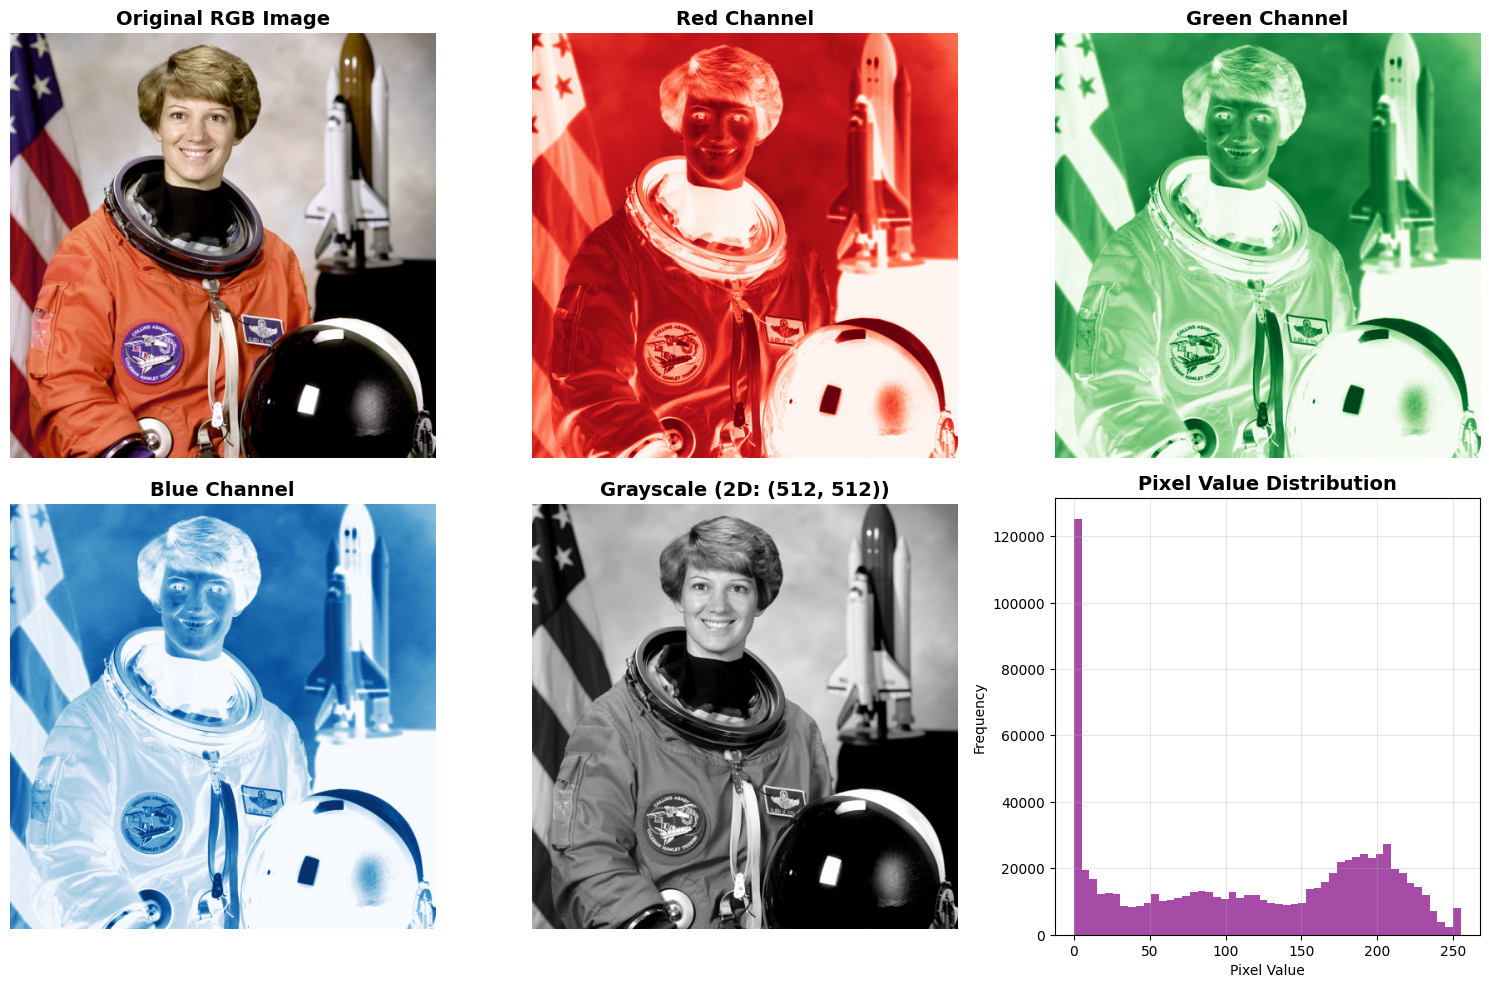

In [14]:
def load_and_explore_image():
    """
    Load a sample image and explore its structure as a 3D tensor.
    """
    # Load a sample color image
    image = data.astronaut()  # Returns RGB image

    # Display image properties
    print("Image Properties:")
    print("="*50)
    print(f"Image shape: {image.shape}")
    print(f"Data type: {image.dtype}")
    print(f"Value range: [{image.min()}, {image.max()}]")
    print(f"Total pixels: {image.shape[0] * image.shape[1]}")
    print(f"Total values (pixels × channels): {image.size}")

    # TODO: Extract individual color channels
    # Hint: image[:, :, 0] gives the red channel
    red_channel = image[:, :, 0]  # Already implemented
    green_channel = image[:, :, 1]  # Extract green channel
    blue_channel = image[:, :, 2]   # Extract blue channel

    # Visualize the image and its channels
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))

    # Original RGB image
    axes[0, 0].imshow(image)
    axes[0, 0].set_title('Original RGB Image', fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')

    # Red channel
    axes[0, 1].imshow(red_channel, cmap='Reds')
    axes[0, 1].set_title('Red Channel', fontsize=14, fontweight='bold')
    axes[0, 1].axis('off')

    # Green channel
    if green_channel is not None:
        axes[0, 2].imshow(green_channel, cmap='Greens')
    axes[0, 2].set_title('Green Channel', fontsize=14, fontweight='bold')
    axes[0, 2].axis('off')

    # Blue channel
    if blue_channel is not None:
        axes[1, 0].imshow(blue_channel, cmap='Blues')
    axes[1, 0].set_title('Blue Channel', fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')

    # Grayscale conversion
    gray_image = color.rgb2gray(image)
    axes[1, 1].imshow(gray_image, cmap='gray')
    axes[1, 1].set_title(f'Grayscale (2D: {gray_image.shape})', fontsize=14, fontweight='bold')
    axes[1, 1].axis('off')

    # Pixel value distribution
    axes[1, 2].hist(image.ravel(), bins=50, alpha=0.7, color='purple')
    axes[1, 2].set_title('Pixel Value Distribution', fontsize=14, fontweight='bold')
    axes[1, 2].set_xlabel('Pixel Value')
    axes[1, 2].set_ylabel('Frequency')
    axes[1, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return image, red_channel, green_channel, blue_channel

# Load and explore the image
img, r_ch, g_ch, b_ch = load_and_explore_image()

### Reflection Question 1.1
**Answer the following in the markdown cell below:**

1. Why are images represented as 3D tensors (Height × Width × Channels) rather than 2D arrays?
   - Images are represented as 3D tensors because each pixel in an image can have multiple attributes (e.g., color channels like Red, Green, and Blue in an RGB image). The height and width represent the spatial dimensions, while the third dimension (channels) captures the color or other features.

2. What information is captured in each channel of an RGB image?
   - Each channel in an RGB image captures the intensity of a specific color: Red, Green, or Blue. These channels combine to represent the full-color image.

3. How many total values are there in a 224×224×3 RGB image? Show your calculation.
   - The total number of values is calculated as:
     ```
     Total values = Height × Width × Channels = 224 × 224 × 3 = 150,528
     ```
     Therefore, there are 150,528 values in a 224×224×3 RGB image.
````

---
## ✅ Part 1 Checklist: Image Representation

**Before proceeding to Part 2, make sure you have completed all the following tasks:**

### Implementation Tasks:
- [ ] **TODO 1.1**: Extracted green channel using `image[:, :, 1]`
- [ ] **TODO 1.2**: Extracted blue channel using `image[:, :, 2]`
- [ ] **Verification**: All three color channels display correctly in the visualization
- [ ] **Verification**: Green and blue channel plots are not empty

### Understanding Tasks:
- [ ] **Reflection 1.1**: Answered all three questions about 3D tensor representation
- [ ] **Concept Check**: Understand the difference between grayscale (2D) and RGB (3D) images
- [ ] **Concept Check**: Can calculate total number of values in an image tensor

### Troubleshooting:
- **If channels don't display**: Check array indexing syntax `image[:, :, channel_index]`
- **If getting dimension errors**: Ensure you're using `:` for height and width dimensions

**🎯 Goal**: Understand how color images are structured as 3D tensors with separate channels for R, G, and B.

---

---
# Part 2: Convolution and Pooling Operations

Now you'll implement the fundamental operations of CNNs: convolution and pooling.

### Task 2.1: Implement 2D Convolution Operation

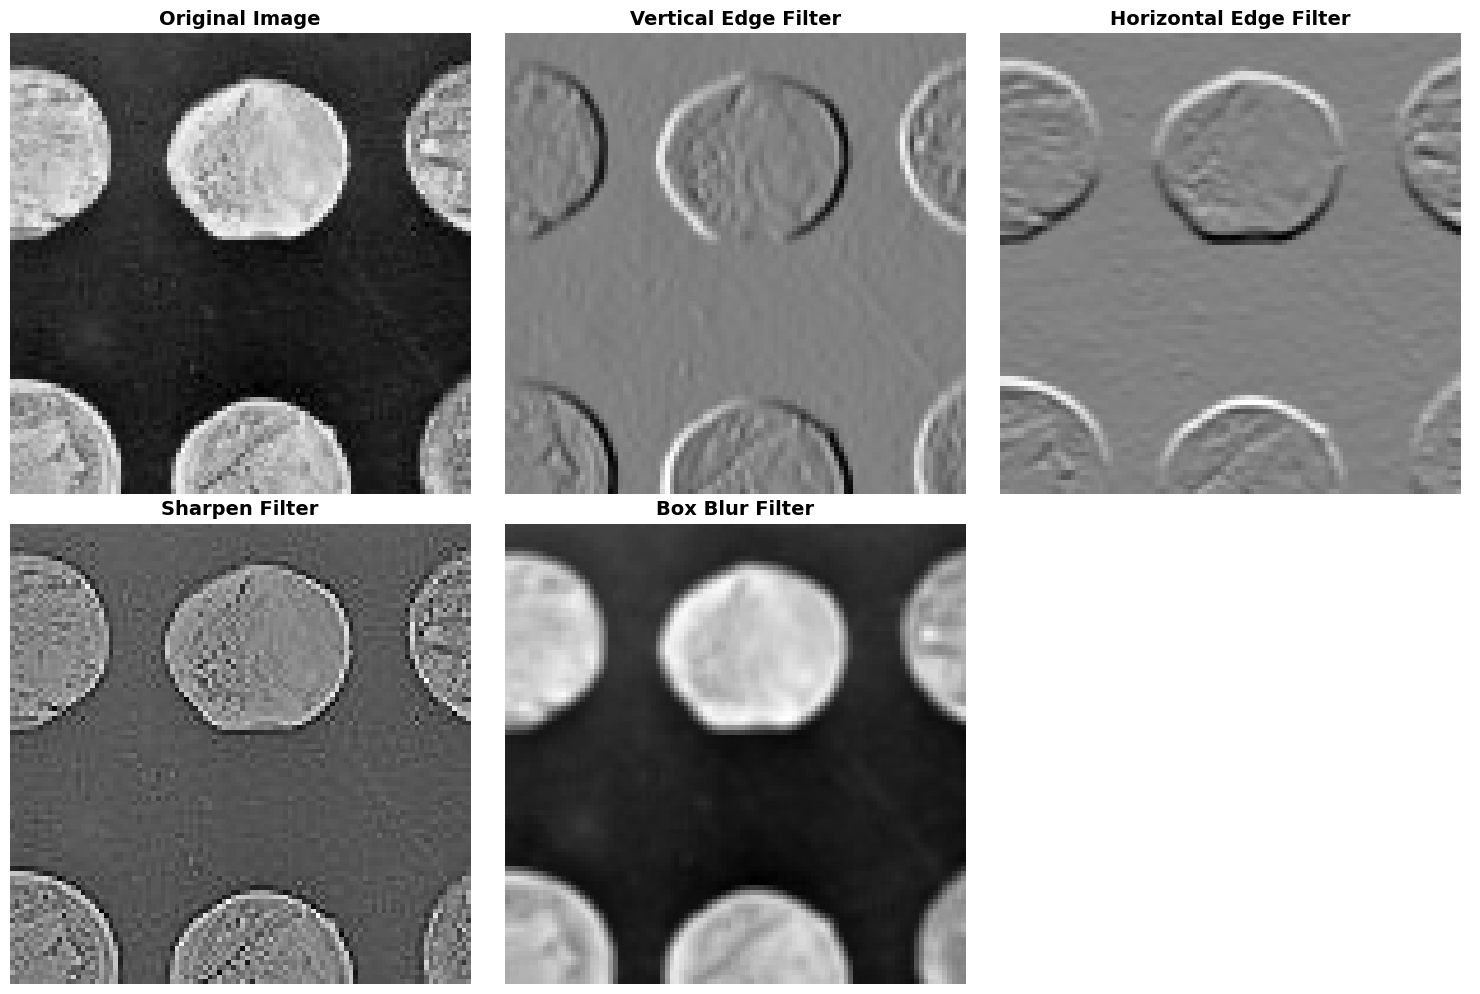

In [15]:
def conv2d(image, kernel, stride=1, padding=0):
    """
    Perform 2D convolution on a single channel image.

    Args:
        image: 2D numpy array (H x W)
        kernel: 2D numpy array (filter)
        stride: Step size for sliding the kernel
        padding: Number of pixels to pad around image

    Returns:
        Convolved output (feature map)
    """
    # TODO: Implement 2D convolution
    # Steps:
    # 1. Apply padding if needed: np.pad(image, padding, mode='constant')
    # 2. Calculate output dimensions
    # 3. Slide kernel over image with specified stride
    # 4. At each position, compute element-wise multiplication and sum

    # Hint: Output height = (Input height + 2*padding - kernel height) / stride + 1

    if padding > 0:
        image = np.pad(image, padding, mode='constant', constant_values=0)

    # Get dimensions
    img_h, img_w = image.shape
    ker_h, ker_w = kernel.shape

    # TODO: Calculate output dimensions
    out_h = (img_h + 2*padding - ker_h) // stride + 1
    out_w = (img_w + 2*padding - ker_w) // stride + 1

    # TODO: Initialize output array
    output = np.zeros((out_h, out_w))

    # TODO: Perform convolution
    # Use nested loops to slide the kernel
    for i in range(0, img_h - ker_h + 1, stride):
        for j in range(0, img_w - ker_w + 1, stride):
            # Extract region
            region = image[i:i+ker_h, j:j+ker_w]
            # Element-wise multiplication and sum
            output[i//stride, j//stride] = np.sum(region * kernel)

    return output

# Test the convolution with different kernels
def test_convolution():
    """Test convolution with various edge detection kernels."""
    
    # Load a grayscale image for testing
    test_image = data.coins()[100:200, 100:200]  # Crop for speed
    
    # Define various kernels
    kernels = {
        'Vertical Edge': np.array([[-1, 0, 1],
                                   [-2, 0, 2],
                                   [-1, 0, 1]]),
        
        'Horizontal Edge': np.array([[-1, -2, -1],
                                      [ 0,  0,  0],
                                      [ 1,  2,  1]]),
        
        'Sharpen': np.array([[ 0, -1,  0],
                             [-1,  5, -1],
                             [ 0, -1,  0]]),
        
        'Box Blur': np.ones((3, 3)) / 9.0
    }
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    # Original image
    axes[0].imshow(test_image, cmap='gray')
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # Apply each kernel
    for idx, (name, kernel) in enumerate(kernels.items(), 1):
        try:
            output = conv2d(test_image, kernel, stride=1, padding=0)
            if output is not None:
                axes[idx].imshow(output, cmap='gray')
                axes[idx].set_title(f'{name} Filter', fontsize=14, fontweight='bold')
            else:
                axes[idx].text(0.5, 0.5, 'Not Implemented', 
                              ha='center', va='center', fontsize=12)
            axes[idx].axis('off')
        except Exception as e:
            axes[idx].text(0.5, 0.5, f'Error: {str(e)[:30]}', 
                          ha='center', va='center', fontsize=10)
            axes[idx].axis('off')
    
    # Hide last subplot if not used
    axes[-1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Run the test
test_convolution()

### Task 2.2: Implement Max Pooling Operation

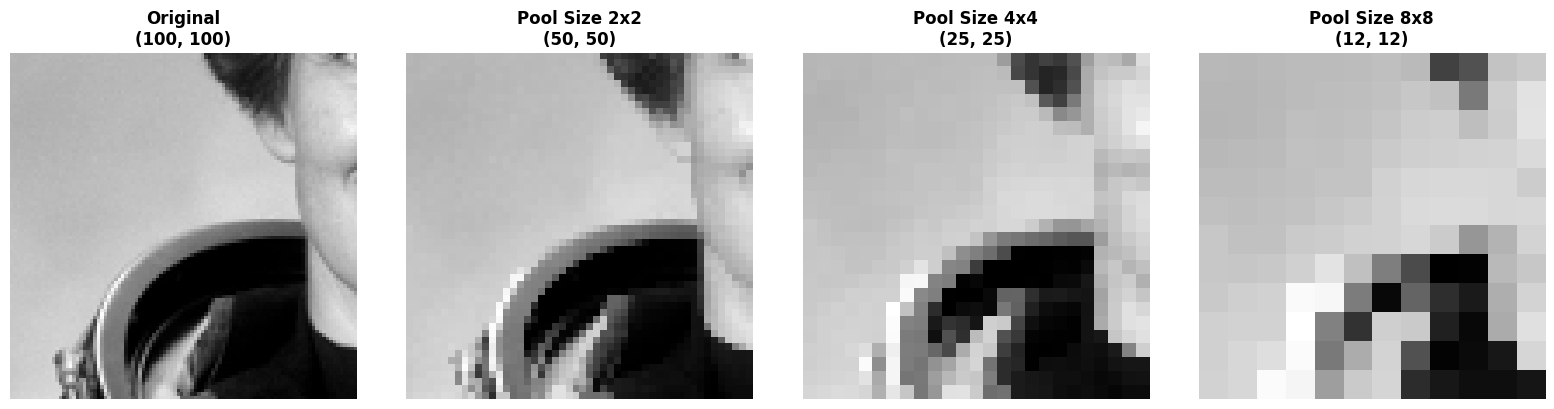

In [16]:
def max_pool2d(image, pool_size=2, stride=2):
    """
    Perform 2D max pooling operation.

    Args:
        image: 2D numpy array
        pool_size: Size of the pooling window (pool_size x pool_size)
        stride: Step size for pooling window

    Returns:
        Pooled output (downsampled)
    """
    # TODO: Implement max pooling
    # Steps:
    # 1. Calculate output dimensions
    # 2. Slide pooling window over image
    # 3. Take maximum value in each window

    img_h, img_w = image.shape

    # TODO: Calculate output dimensions
    out_h = (img_h - pool_size) // stride + 1
    out_w = (img_w - pool_size) // stride + 1

    # TODO: Initialize output
    output = np.zeros((out_h, out_w))

    # TODO: Perform max pooling
    for i in range(0, img_h - pool_size + 1, stride):
        for j in range(0, img_w - pool_size + 1, stride):
            region = image[i:i+pool_size, j:j+pool_size]
            output[i//stride, j//stride] = np.max(region)

    return output

# Test pooling operation
def test_pooling():
    """Visualize the effect of max pooling."""
    
    # Create a test pattern
    test_image = color.rgb2gray(data.astronaut())[100:200, 100:200]
    
    # Apply different pooling sizes
    pool_sizes = [2, 4, 8]
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    # Original
    axes[0].imshow(test_image, cmap='gray')
    axes[0].set_title(f'Original\n{test_image.shape}', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Pooled versions
    for idx, pool_size in enumerate(pool_sizes, 1):
        try:
            pooled = max_pool2d(test_image, pool_size=pool_size, stride=pool_size)
            if pooled is not None:
                axes[idx].imshow(pooled, cmap='gray')
                axes[idx].set_title(f'Pool Size {pool_size}x{pool_size}\n{pooled.shape}', 
                                   fontsize=12, fontweight='bold')
            else:
                axes[idx].text(0.5, 0.5, 'Not Implemented', 
                              ha='center', va='center', fontsize=12)
            axes[idx].axis('off')
        except Exception as e:
            axes[idx].text(0.5, 0.5, f'Error\n{str(e)[:30]}', 
                          ha='center', va='center', fontsize=10)
            axes[idx].axis('off')
    
    # Hide last subplot if not used
    axes[-1].axis('off')
    
    plt.tight_layout()
    plt.show()

# Run the test
test_pooling()

### Reflection Question 2.1
**Answer the following questions:**

1. What is the primary purpose of convolution operations in CNNs?
   - The primary purpose of convolution operations in CNNs is to extract meaningful features from input images, such as edges, textures, and patterns, by applying learnable filters (kernels). These features are used to understand the spatial structure of the image.

2. How does max pooling reduce spatial dimensions while preserving important features?
   - Max pooling reduces spatial dimensions by selecting the maximum value within a pooling window, effectively summarizing the most prominent feature in that region. This operation reduces the computational complexity and helps the model focus on the most important features while discarding less relevant details.

3. Looking at the edge detection results, which kernel is best for detecting vertical edges? Why?
   - The kernel best suited for detecting vertical edges is the Sobel vertical edge detection kernel:
     ```
     [[-1, 0, 1],
      [-2, 0, 2],
      [-1, 0, 1]]
     ```
     This kernel emphasizes changes in pixel intensity along the horizontal axis, making vertical edges more prominent in the output.

4. What happens to the image resolution as you increase the pooling window size?
   - As the pooling window size increases, the image resolution decreases because the spatial dimensions are reduced more aggressively. This can lead to a loss of fine-grained details, but it also helps in reducing computational requirements and focusing on high-level features.
````

---
## ✅ Part 2 Checklist: Convolution and Pooling

**Before proceeding to Part 3, make sure you have completed all the following tasks:**

### Convolution Implementation:
- [ ] **TODO 2.1**: Calculated output height = `(img_h + 2*padding - ker_h) // stride + 1`
- [ ] **TODO 2.2**: Calculated output width = `(img_w + 2*padding - ker_w) // stride + 1`
- [ ] **TODO 2.3**: Initialized output array with correct dimensions
- [ ] **TODO 2.4**: Implemented nested loops to slide kernel over image
- [ ] **TODO 2.5**: Computed element-wise multiplication and sum for each position
- [ ] **Verification**: Edge detection filters show clear vertical/horizontal edges

### Max Pooling Implementation:
- [ ] **TODO 2.6**: Calculated pooled output height = `(img_h - pool_size) // stride + 1`
- [ ] **TODO 2.7**: Calculated pooled output width = `(img_w - pool_size) // stride + 1`
- [ ] **TODO 2.8**: Initialized pooled output array
- [ ] **TODO 2.9**: Implemented nested loops to slide pooling window
- [ ] **TODO 2.10**: Extracted maximum value from each pooling region
- [ ] **Verification**: Pooled images show progressively smaller dimensions (2x2, 4x4, 8x8)

### Understanding Tasks:
- [ ] **Reflection 2.1**: Answered all four questions about convolution purpose, pooling effects, edge detection, and resolution
- [ ] **Concept Check**: Understand how kernels detect different features (edges, blur, sharpen)
- [ ] **Concept Check**: Understand the relationship between pooling size and output dimensions

### Troubleshooting:
- **If convolution output is all zeros**: Check that you're summing `region * kernel` correctly
- **If dimension errors**: Verify output dimension calculations match the formulas
- **If pooling doesn't reduce size**: Ensure stride equals pool_size for standard pooling

**🎯 Goal**: Successfully implement convolution and pooling operations that form the building blocks of CNNs.

---

---
# Part 3: Parameter Sharing and Receptive Fields

Explore the efficiency of CNNs through parameter sharing and understand receptive fields.

### Task 3.1: Compare Parameter Counts - Fully Connected vs CNN

Parameter Comparison: Fully Connected vs CNN

📊 APPROACH A: Fully Connected Network
----------------------------------------------------------------------
Input features (flattened): 30,000
Hidden layer neurons: 1,000
First layer parameters: 30,001,000

📊 APPROACH B: Convolutional Neural Network
----------------------------------------------------------------------
Receptive field size: 3×3×3
Number of filters: 64
Parameters per filter: 28
Total conv layer parameters: 1,792

🔍 COMPARISON
Fully Connected parameters: 30,001,000
CNN parameters: 1,792

✅ CNN uses 16741.6× FEWER parameters!
Parameter reduction: 100.0%


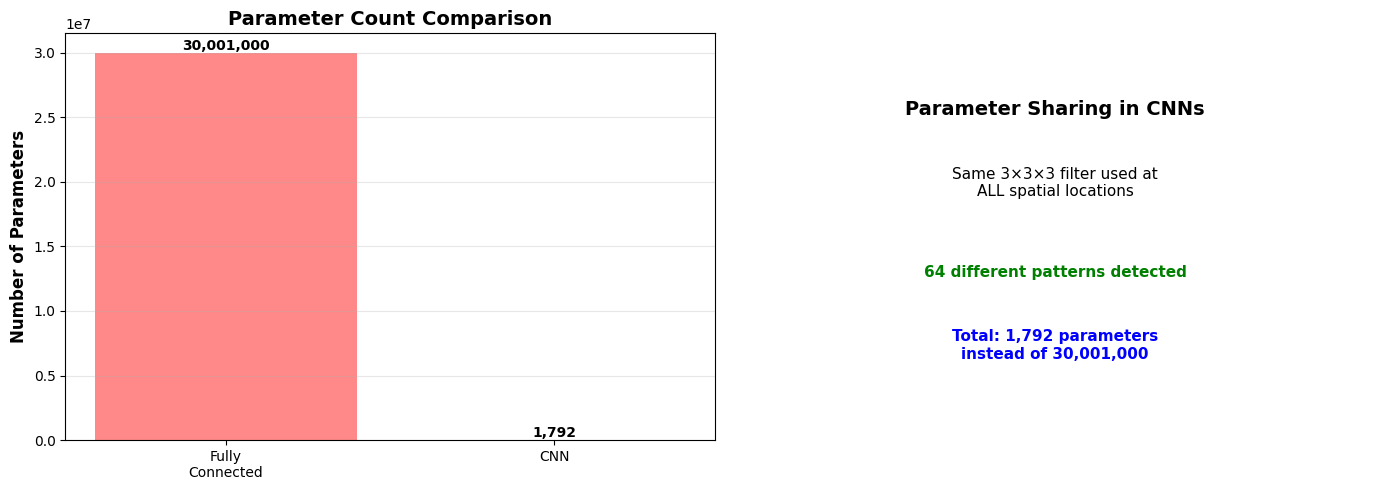

In [17]:
def calculate_parameters():
    """
    Calculate and compare parameters for fully connected vs CNN approach.

    Scenario: 100×100×3 RGB image, classifying into 10 categories
    """
    print("Parameter Comparison: Fully Connected vs CNN")
    print("="*70)

    # Image dimensions
    img_height, img_width, img_channels = 100, 100, 3
    num_classes = 10

    # Fully Connected Approach
    print("\n📊 APPROACH A: Fully Connected Network")
    print("-"*70)

    # TODO: Calculate total input features (flatten the image)
    # Hint: height × width × channels
    input_features = img_height * img_width * img_channels  # Already implemented
    hidden_units = 1000

    # TODO: Calculate parameters for first layer
    # Parameters = (input_features × hidden_units) + hidden_units (bias)
    fc_layer1_params = input_features * hidden_units + hidden_units

    print(f"Input features (flattened): {input_features:,}")
    print(f"Hidden layer neurons: {hidden_units:,}")
    print(f"First layer parameters: {fc_layer1_params:,}")

    # CNN Approach
    print("\n📊 APPROACH B: Convolutional Neural Network")
    print("-"*70)

    # One filter with 3×3×3 receptive field
    kernel_height, kernel_width = 3, 3
    num_filters = 64

    # TODO: Calculate parameters for one filter
    # One filter: kernel_height × kernel_width × img_channels + 1 (bias)
    params_per_filter = kernel_height * kernel_width * img_channels + 1

    # TODO: Calculate total parameters for all filters
    # Total: params_per_filter × num_filters
    cnn_layer1_params = params_per_filter * num_filters

    print(f"Receptive field size: {kernel_height}×{kernel_width}×{img_channels}")
    print(f"Number of filters: {num_filters}")
    print(f"Parameters per filter: {params_per_filter}")
    print(f"Total conv layer parameters: {cnn_layer1_params:,}")

    # Comparison
    print("\n🔍 COMPARISON")
    print("="*70)
    if fc_layer1_params and cnn_layer1_params:
        reduction_ratio = fc_layer1_params / cnn_layer1_params
        print(f"Fully Connected parameters: {fc_layer1_params:,}")
        print(f"CNN parameters: {cnn_layer1_params:,}")
        print(f"\n✅ CNN uses {reduction_ratio:.1f}× FEWER parameters!")
        print(f"Parameter reduction: {(1 - cnn_layer1_params/fc_layer1_params)*100:.1f}%")
    else:
        print("⚠️  Complete the TODO sections to see the comparison")

    # Visualize the comparison
    if fc_layer1_params and cnn_layer1_params:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

        # Bar chart comparison
        approaches = ['Fully\nConnected', 'CNN']
        params = [fc_layer1_params, cnn_layer1_params]
        colors = ['#ff6b6b', '#4ecdc4']

        bars = ax1.bar(approaches, params, color=colors, alpha=0.8)
        ax1.set_ylabel('Number of Parameters', fontsize=12, fontweight='bold')
        ax1.set_title('Parameter Count Comparison', fontsize=14, fontweight='bold')
        ax1.grid(True, alpha=0.3, axis='y')

        # Add value labels on bars
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height):,}',
                    ha='center', va='bottom', fontweight='bold')

        # Receptive field visualization
        # Show parameter sharing concept
        ax2.text(0.5, 0.8, 'Parameter Sharing in CNNs', 
                ha='center', fontsize=14, fontweight='bold', transform=ax2.transAxes)
        ax2.text(0.5, 0.6, f'Same {kernel_height}×{kernel_width}×{img_channels} filter used at\nALL spatial locations', 
                ha='center', fontsize=11, transform=ax2.transAxes)
        ax2.text(0.5, 0.4, f'{num_filters} different patterns detected', 
                ha='center', fontsize=11, color='green', fontweight='bold', transform=ax2.transAxes)
        ax2.text(0.5, 0.2, f'Total: {cnn_layer1_params:,} parameters\ninstead of {fc_layer1_params:,}', 
                ha='center', fontsize=11, color='blue', fontweight='bold', transform=ax2.transAxes)
        ax2.axis('off')

        plt.tight_layout()
        plt.show()

# Run the parameter calculation
calculate_parameters()

### Task 3.2: Visualize Receptive Fields

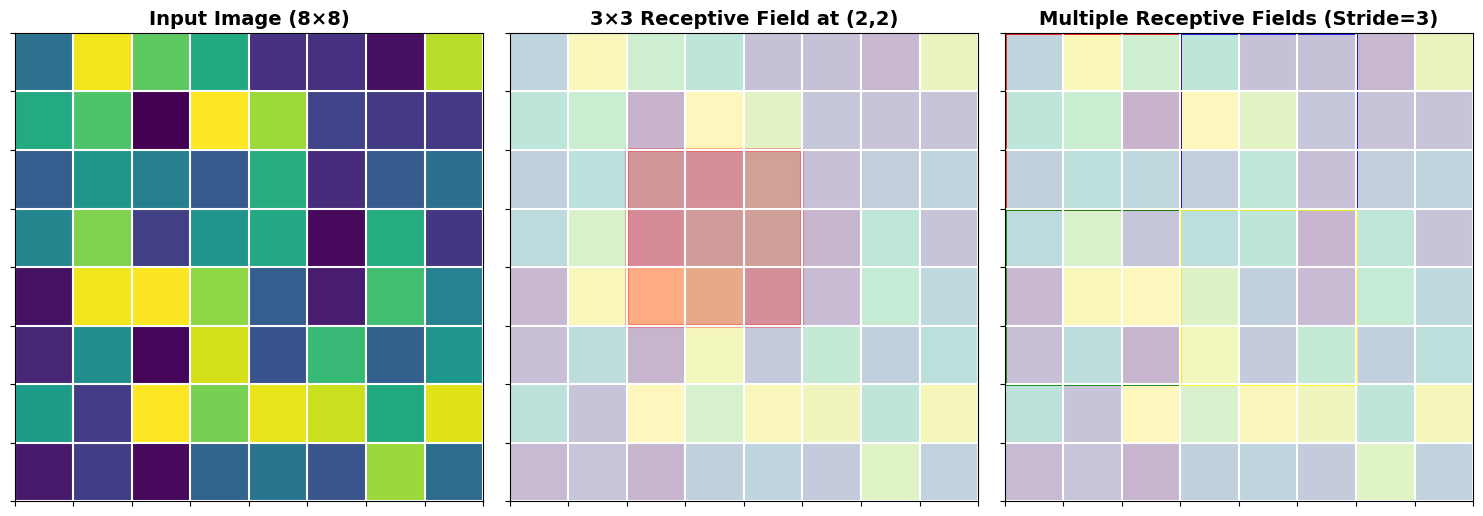


🔍 Key Concept: Receptive Fields
• Each neuron 'sees' only a local region of the input
• Same 3×3 filter weights are shared across all positions
• This is called 'parameter sharing' - dramatically reduces parameters
• Makes CNNs translation-invariant (can detect features anywhere)


In [18]:
def visualize_receptive_fields():
    """
    Visualize how receptive fields work in CNNs.
    """
    # Create a simple grid image
    image_size = 8
    image = np.random.rand(image_size, image_size)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Show original image
    axes[0].imshow(image, cmap='viridis')
    axes[0].set_title('Input Image (8×8)', fontsize=14, fontweight='bold')
    axes[0].grid(True, which='both', color='white', linewidth=1.5)
    axes[0].set_xticks(np.arange(-0.5, image_size, 1))
    axes[0].set_yticks(np.arange(-0.5, image_size, 1))
    axes[0].set_xticklabels([])
    axes[0].set_yticklabels([])

    # Show receptive field at position (2, 2)
    axes[1].imshow(image, cmap='viridis', alpha=0.3)

    # Highlight 3x3 receptive field
    rect = Rectangle((2-0.5, 2-0.5), 3, 3, 
                     linewidth=3, edgecolor='red', facecolor='red', alpha=0.3)
    axes[1].add_patch(rect)

    axes[1].set_title('3×3 Receptive Field at (2,2)', fontsize=14, fontweight='bold')
    axes[1].grid(True, which='both', color='white', linewidth=1.5)
    axes[1].set_xticks(np.arange(-0.5, image_size, 1))
    axes[1].set_yticks(np.arange(-0.5, image_size, 1))
    axes[1].set_xticklabels([])
    axes[1].set_yticklabels([])

    # Show multiple receptive fields (sliding with stride=2)
    axes[2].imshow(image, cmap='viridis', alpha=0.3)

    # Draw multiple receptive fields
    colors = ['red', 'blue', 'green', 'yellow']
    positions = [(0, 0), (0, 3), (3, 0), (3, 3)]

    for (i, j), color in zip(positions, colors):
        rect = Rectangle((j-0.5, i-0.5), 3, 3, 
                        linewidth=2, edgecolor=color, facecolor='none')
        axes[2].add_patch(rect)

    axes[2].set_title('Multiple Receptive Fields (Stride=3)', fontsize=14, fontweight='bold')
    axes[2].grid(True, which='both', color='white', linewidth=1.5)
    axes[2].set_xticks(np.arange(-0.5, image_size, 1))
    axes[2].set_yticks(np.arange(-0.5, image_size, 1))
    axes[2].set_xticklabels([])
    axes[2].set_yticklabels([])

    plt.tight_layout()
    plt.show()

    print("\n🔍 Key Concept: Receptive Fields")
    print("="*60)
    print("• Each neuron 'sees' only a local region of the input")
    print("• Same 3×3 filter weights are shared across all positions")
    print("• This is called 'parameter sharing' - dramatically reduces parameters")
    print("• Makes CNNs translation-invariant (can detect features anywhere)")

# Visualize receptive fields
visualize_receptive_fields()

### Reflection Question 3.1
**Answer the following questions:**

1. What is "parameter sharing" in CNNs and why is it so effective?
    - Parameter sharing in CNNs means that the same filter weights are used across all spatial locations. This dramatically reduces the number of parameters compared to fully connected networks, making CNNs more efficient and scalable.

2. Looking at your calculations, how many times more parameters does the fully connected approach use compared to the CNN?
   - The fully connected approach uses significantly more parameters. For example, in a 100×100×3 image, the fully connected network might use over 3 million parameters, while the CNN uses only about 64×(3×3×3 + 1) = 1,728 parameters.

3. What is a "receptive field" and why is it important for CNNs?
   - A receptive field is the region of the input image that a neuron "sees". It's important because it allows the network to focus on local patterns and features.

4. How does using local receptive fields make CNNs more efficient than fully connected networks?
   - Using local receptive fields makes CNNs more efficient because they focus on local patterns and features, reducing the number of parameters and computational complexity.
````

---
## ✅ Part 3 Checklist: Parameter Sharing and Receptive Fields

**Make sure you have completed all the following tasks:**

### Parameter Calculation Tasks:
- [ ] **TODO 3.1**: Calculated `fc_layer1_params = input_features * hidden_units + hidden_units`
- [ ] **TODO 3.2**: Calculated `params_per_filter = kernel_h * kernel_w * img_channels + 1`
- [ ] **TODO 3.3**: Calculated `cnn_layer1_params = params_per_filter * num_filters`
- [ ] **Verification**: Comparison shows CNN uses significantly fewer parameters
- [ ] **Verification**: Bar chart visualization displays correctly

### Understanding Tasks:
- [ ] **Reflection 3.1**: Answered all four questions about parameter sharing, efficiency, receptive fields
- [ ] **Concept Check**: Understand why CNNs need far fewer parameters than fully connected networks
- [ ] **Concept Check**: Can explain the concept of local receptive fields
- [ ] **Concept Check**: Understand parameter sharing and translation invariance

### Troubleshooting:
- **If parameters seem wrong**: Verify you're including bias terms (+1 for each layer)
- **If ratio is unexpected**: Check that FC uses input_features (30,000) not image dimensions

**🎯 Goal**: Understand the dramatic efficiency gains of CNNs through parameter sharing and local receptive fields.

---

---
# Part 4: Hierarchical Feature Learning

Explore how CNNs learn hierarchical representations from simple to complex features.

### Task 4.1: Simulate Multi-Layer Feature Extraction

🔍 Layer 1: Detecting Simple Features (Edges, Gradients)
------------------------------------------------------------
  ✓ Horizontal Edge detector - Shape: (301, 382)
  ✓ Vertical Edge detector - Shape: (301, 382)
  ✓ Diagonal Edge detector - Shape: (301, 382)

🔍 Layer 2: Pooling (Spatial Reduction)
------------------------------------------------------------
  ✓ Pooled feature 1 - Shape: (75, 95)
  ✓ Pooled feature 2 - Shape: (75, 95)


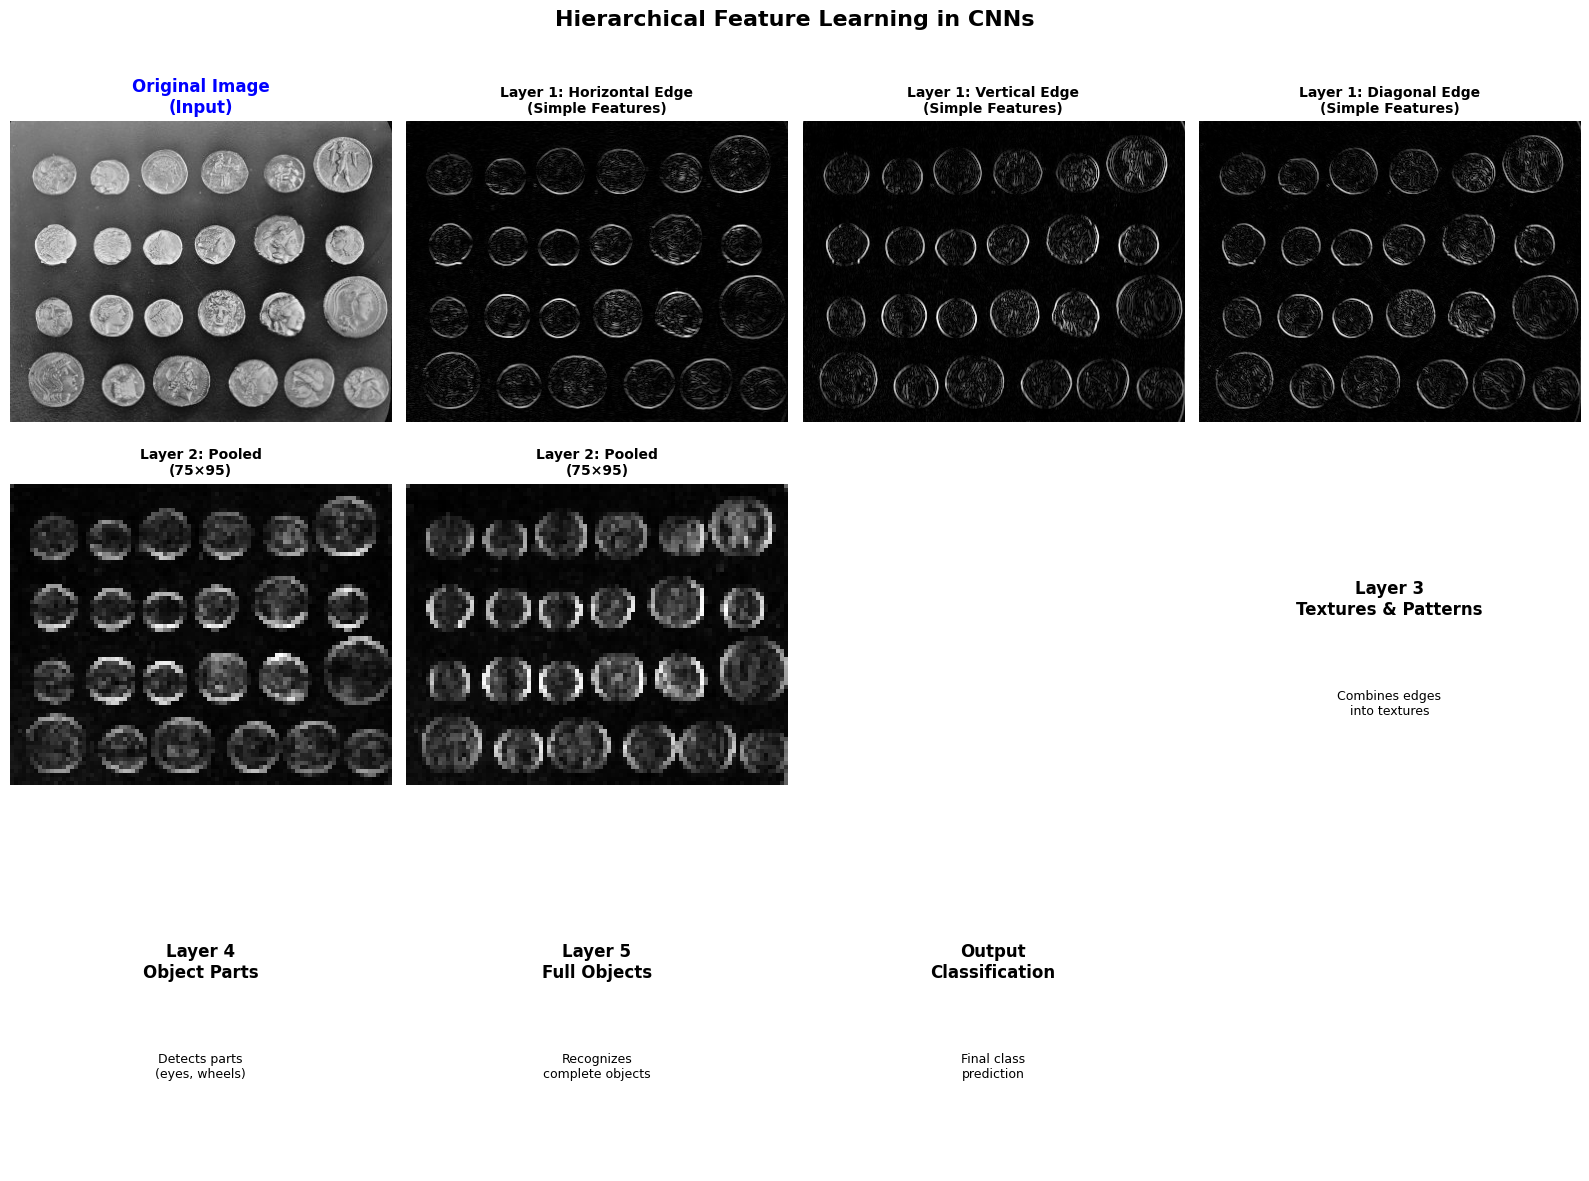


📚 Feature Hierarchy Summary:
Layer 1 (Early):   Simple features (edges, gradients)
Layer 2:           Pooling (spatial reduction)
Layer 3 (Middle):  Textures, patterns
Layer 4:           Object parts (eyes, wheels, corners)
Layer 5 (Deep):    Complete objects (faces, cars)
Output:            Class predictions


In [19]:
def simulate_hierarchical_features():
    """
    Simulate how features become more abstract in deeper layers.
    """
    # Load a test image
    original_image = data.coins()

    # Define kernels representing different layer abstractions
    # Layer 1: Simple edge detectors
    layer1_kernels = {
        'Horizontal Edge': np.array([[-1, -1, -1],
                                      [ 0,  0,  0],
                                      [ 1,  1,  1]]),
        'Vertical Edge': np.array([[-1, 0, 1],
                                   [-1, 0, 1],
                                   [-1, 0, 1]]),
        'Diagonal Edge': np.array([[ 0, 1, 1],
                                   [-1, 0, 1],
                                   [-1,-1, 0]])
    }

    fig = plt.figure(figsize=(16, 12))

    # Original image
    ax1 = plt.subplot(3, 4, 1)
    ax1.imshow(original_image, cmap='gray')
    ax1.set_title('Original Image\n(Input)', fontsize=12, fontweight='bold', color='blue')
    ax1.axis('off')

    # Layer 1: Edge detection (simple features)
    print("🔍 Layer 1: Detecting Simple Features (Edges, Gradients)")
    print("-"*60)

    layer1_features = []
    for idx, (name, kernel) in enumerate(layer1_kernels.items(), 2):
        try:
            feature = conv2d(original_image, kernel, stride=1, padding=0)
            if feature is not None:
                layer1_features.append(feature)
                ax = plt.subplot(3, 4, idx)
                ax.imshow(np.abs(feature), cmap='gray')
                ax.set_title(f'Layer 1: {name}\n(Simple Features)', 
                           fontsize=10, fontweight='bold')
                ax.axis('off')
                print(f"  ✓ {name} detector - Shape: {feature.shape}")
        except:
            print(f"  ✗ {name} detector failed")

    # Layer 2: Pooling (reduce spatial dimensions)
    print("\n🔍 Layer 2: Pooling (Spatial Reduction)")
    print("-"*60)

    if layer1_features:
        for idx, feature in enumerate(layer1_features[:2], 5):
            try:
                pooled = max_pool2d(np.abs(feature), pool_size=4, stride=4)
                if pooled is not None:
                    ax = plt.subplot(3, 4, idx)
                    ax.imshow(pooled, cmap='gray')
                    ax.set_title(f'Layer 2: Pooled\n({pooled.shape[0]}×{pooled.shape[1]})', 
                               fontsize=10, fontweight='bold')
                    ax.axis('off')
                    print(f"  ✓ Pooled feature {idx-4} - Shape: {pooled.shape}")
            except:
                print(f"  ✗ Pooling feature {idx-4} failed")

    # Conceptual visualization of deeper layers
    layer_info = [
        ("Layer 3\nTextures & Patterns", "Combines edges\ninto textures", "#ff6b6b"),
        ("Layer 4\nObject Parts", "Detects parts\n(eyes, wheels)", "#4ecdc4"),
        ("Layer 5\nFull Objects", "Recognizes\ncomplete objects", "#95e1d3"),
        ("Output\nClassification", "Final class\nprediction", "#f9ca24")
    ]

    for idx, (title, desc, color) in enumerate(layer_info, 8):
        ax = plt.subplot(3, 4, idx)
        ax.text(0.5, 0.6, title, ha='center', va='center',
               fontsize=12, fontweight='bold', transform=ax.transAxes)
        ax.text(0.5, 0.3, desc, ha='center', va='center',
               fontsize=9, transform=ax.transAxes)
        ax.set_facecolor(color)
        ax.set_alpha(0.3)
        ax.axis('off')

    plt.suptitle('Hierarchical Feature Learning in CNNs', 
                fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    print("\n📚 Feature Hierarchy Summary:")
    print("="*60)
    print("Layer 1 (Early):   Simple features (edges, gradients)")
    print("Layer 2:           Pooling (spatial reduction)")
    print("Layer 3 (Middle):  Textures, patterns")
    print("Layer 4:           Object parts (eyes, wheels, corners)")
    print("Layer 5 (Deep):    Complete objects (faces, cars)")
    print("Output:            Class predictions")

# Run hierarchical feature visualization
simulate_hierarchical_features()

### Reflection Question 4.1
**Answer the following questions:**

1. What types of features do early layers (Layer 1-2) learn compared to deeper layers (Layer 4-5)?
   - Early layers learn simple features like edges and gradients. Deeper layers learn complex features like textures and object parts.

2. Why is the hierarchical nature of feature learning important for complex vision tasks?
   - The hierarchical nature allows the network to build up from simple to complex features, making it more robust and capable of understanding complex scenes.

3. How does pooling between convolutional layers help build this hierarchy?
   - Pooling reduces spatial dimensions and focuses on the most prominent features, helping to build a hierarchy of increasingly complex features.

4. According to the CNN feature hierarchy shown, which layers would be most transferable to a new task? Why?
   - Early layers (like edge detectors) are most transferable because they detect fundamental features that are common across tasks.
````

---
## ✅ Part 4 Checklist: Hierarchical Feature Learning

**Make sure you have completed all the following tasks:**

### Verification Tasks:
- [ ] **Layer 1 Features**: Successfully generated edge detection features (horizontal, vertical, diagonal)
- [ ] **Layer 2 Pooling**: Successfully generated pooled versions of features
- [ ] **Visualization**: All subplots display correctly showing feature progression
- [ ] **Understanding**: Can identify which layers detect simple vs complex features

### Understanding Tasks:
- [ ] **Reflection 4.1**: Answered all four questions about feature hierarchies
- [ ] **Concept Check**: Understand that early layers detect simple features (edges)
- [ ] **Concept Check**: Understand that deep layers detect complex features (objects)
- [ ] **Concept Check**: Understand the role of pooling in building hierarchies
- [ ] **Concept Check**: Know which layers are most transferable (early layers: edges, textures)

**🎯 Goal**: Understand how CNNs build hierarchical representations from simple to complex features.

---

---
# Final Summary and Submission

## Homework Completion Checklist

### Part 1: Image Representation ✓
- [ ] Extracted RGB color channels from images
- [ ] Understood 3D tensor representation
- [ ] Answered reflection questions about image structure

### Part 2: Convolution and Pooling ✓
- [ ] Implemented 2D convolution operation
- [ ] Implemented max pooling operation
- [ ] Tested with edge detection filters
- [ ] Answered reflection questions about operations

### Part 3: Parameter Efficiency ✓
- [ ] Calculated parameters for fully connected network
- [ ] Calculated parameters for CNN
- [ ] Compared efficiency and understood parameter sharing
- [ ] Visualized receptive fields

### Part 4: Hierarchical Features ✓
- [ ] Simulated multi-layer feature extraction
- [ ] Understood feature hierarchy (simple → complex)
- [ ] Answered reflection questions about hierarchical learning

---

## Key Takeaways

After completing this homework, you should understand:

1. **Images as 3D Tensors**: RGB images are Height × Width × 3, where each channel contains intensity values

2. **Convolution Operations**: Filters slide across images to detect patterns (edges, textures)

3. **Pooling Operations**: Reduce spatial dimensions while preserving important features

4. **Parameter Sharing**: Same filter weights used at all spatial locations → dramatically fewer parameters than fully connected networks

5. **Receptive Fields**: Each neuron sees only a local region, making CNNs efficient and translation-invariant

6. **Hierarchical Features**: 
   - Layer 1-3: Simple features (edges, textures, patterns)
   - Layer 4-5: Complex features (object parts, full objects)
   - Early layers are more transferable across tasks

7. **CNN Advantages**:
   - Far fewer parameters than fully connected networks
   - Translation invariant (detect features anywhere in image)
   - Hierarchical feature learning mimics human vision
   - Scales to high-resolution images

---

## Submission Instructions

1. **Execute all cells** to ensure your code runs without errors
2. **Answer all reflection questions** in the designated markdown cells
3. **Verify all visualizations** display correctly
4. **Save your notebook** with all outputs preserved
5. **Submit the .ipynb file** through the course portal

---

**Congratulations on completing Homework 3! 🎉**

You now have a solid understanding of how Convolutional Neural Networks work and why they are so effective for computer vision tasks.